In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
np.random.seed(42)

x = np.random.randn(100)

noise = np.random.randn(100)

TRUE_W = 2.0
TRUE_B = 1.0

y = TRUE_W * x + TRUE_B + noise


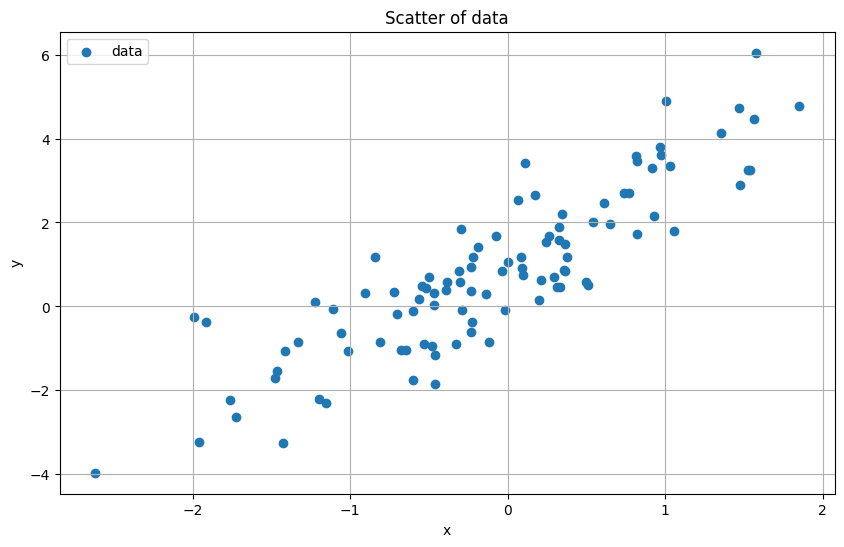

In [4]:
plt.figure(figsize=(10, 6))
plt.scatter(x=x, y=y, label='data')
plt.title('Scatter of data')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.legend()
plt.show()

In [5]:
#Mean Square Error - MSE
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

#Predict y
def predict(w, x, b):
    return w * x + b

1. In notebook 02 you eyeballed `w, b` and computed MSE. What's wrong with eyeballing as a strategy when you have 50 features instead of 1?
   - It becomes complex when you have more features in order to eyeball `w, b`.
   - It takes more time to compute `w, b`.
   - It is hectic to calculate.
   - More importantly, you cannot easily guess what will give low MSE.
2. The MSE surface is a **bowl** in `(w, b)` space. If a blindfolded person stood on the bowl and wanted to reach the bottom, what's the one piece of local info they'd need at every step?
   - The person might need the slope, how much slope it has, is it very steep down, its not that much steep or its managable steep.
3. Define **gradient** in one sentence — not the textbook def, *your* def.
   - Gardient can be anything pointing to upward direction, if w is positive and
     it can downward, if it is negative, if it is zero, then there is no slope.
     And gradient will define, what is the rate of change error(MSE) w.r.t change in w,
     what is the rate of change error(MSE) w.r.t change in b
4. Why "descent" and not "ascent"?
   - ascent means bigger loss, we do not want bigger loss, descent means less loss, inorder to have loss we should be moving towards descent.
5. What's the role of **learning rate** — 1 sentence.
   - learning rate will be how much unit you should move not very high, not very less,
     how much sufficient.

For linreg with ŷ = w·x + b and MSE = (1/n) Σ (y_i − ŷ_i)²

- the rate of change of MSE w.r.t w is : (-2/n) Σ x_i (y_i − ŷ_i)
- the rate of change of MSE w.r.t b is : (-2/n) Σ (y_i − ŷ_i)

Gradient is nothing but the rate of change of MSE w.r.t w, and rate of change of MSE w.r.t b


In [6]:
n = 100
x = np.random.uniform(0, 10, n)

y = 3 * x + 5 + np.random.normal(0, 2, n) #True_w = 3 and True_b = 5
print(mse(y, predict(w=3, x=x, b=5)))

2.573584643131884


In [7]:
def gradients(x, y, w, b):
    y_cap = predict(w=w,x=x, b=b)
    error = y - y_cap
    dw = (-2/n) * np.sum(x * error)
    db = (-2/n) * np.sum(error)
    return dw, db

dw_true, db_true = gradients(x=x,y=y,w=3,b=5)
print(f'dw_true is :{dw_true:.4f}, db_true is : {db_true:.4f}')
# got dw_true is :-0.7413, db_true is : -0.2159, so increase dw_true and db__true

dw_fake, db_fake = gradients(x=x,y=y,w=0,b=0)
print(f'dw_fake is :{dw_fake:.4f}, db_fake is : {db_fake:.4f}')


dw_true is :-0.9893, db_true is : -0.3392
dw_fake is :-237.2017, db_fake is : -39.5788


In [ ]:
def gradiant_descent(x, y, lr=0.01, epochs=1000):
    w, b = 0, 0
    
    history = []

    for epoch in range(epochs):
        dw, db = gradients(x, y, w, b)
        w = w - lr * dw
        b = b - lr * db
        loss = mse(y_true=y, y_pred=predict(w,x=x,b=b))
        history.append(loss)
        if epoch % 100 == 0:
            print(f'epoch {epoch}, | w = {w:.3f}, b = {b:.3f} | loss = {loss:.3f}')
    return w, b, history
    
w_hat, b_hat, hist = gradiant_descent(x=x, y=y, lr=0.01, epochs=1000)
print(len(hist))
print(f"\nFinal: w={w_hat:.3f} (truth 3.0), b={b_hat:.3f} (truth 5.0)")



epoch 0, | w = 2.372, b = 0.396 | loss = 66.459
epoch 100, | w = 3.425, b = 2.397 | loss = 4.674
epoch 200, | w = 3.249, b = 3.517 | loss = 3.368
epoch 300, | w = 3.139, b = 4.217 | loss = 2.858
epoch 400, | w = 3.071, b = 4.655 | loss = 2.658
epoch 500, | w = 3.028, b = 4.928 | loss = 2.580
epoch 600, | w = 3.001, b = 5.100 | loss = 2.550
epoch 700, | w = 2.984, b = 5.207 | loss = 2.538
epoch 800, | w = 2.973, b = 5.274 | loss = 2.533
epoch 900, | w = 2.967, b = 5.316 | loss = 2.531
1000
w_hat : 2.96262217347947 truth_w : 3 | b_hat : 5.34149427026757 truth_b : 5
